# Customer Churn Prevention

In [1]:
## Problem Statement
# Identify users likely to stop using subscription before they actually churn, allowing the platform to send targeted "we miss you" offers.

In [2]:
## Importing Libraries
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [5]:
# ================================
# 1. Load Data and EDA
# ================================
df = pd.read_csv("Customer_Churn_Prevention.csv")

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.drop('customerID', axis=1, inplace=True, errors='ignore')
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

### Basic Inspection
display(df.head(5))
display(df.shape)
display(df.columns)
display(df.info())
display(df.describe())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


(7043, 20)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

None

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441,0.265370
std,0.368612,24.559481,30.090047,2266.771362,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


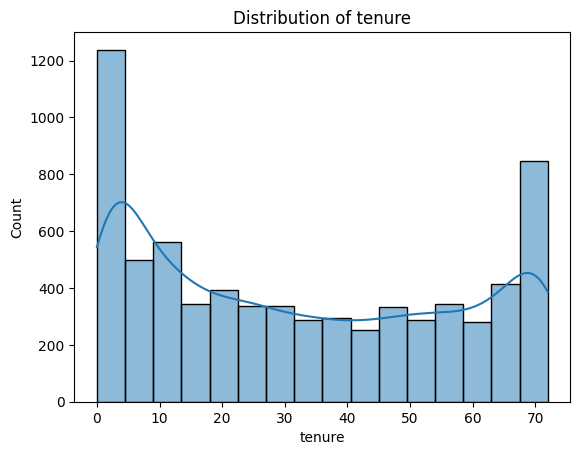

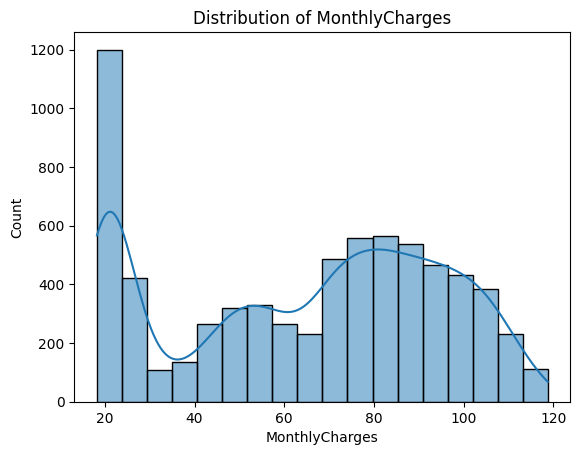

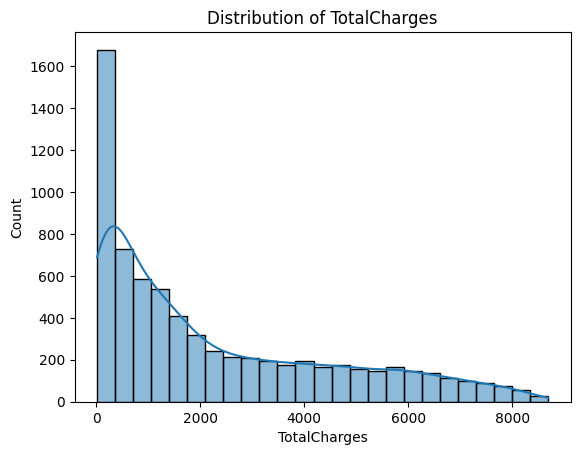

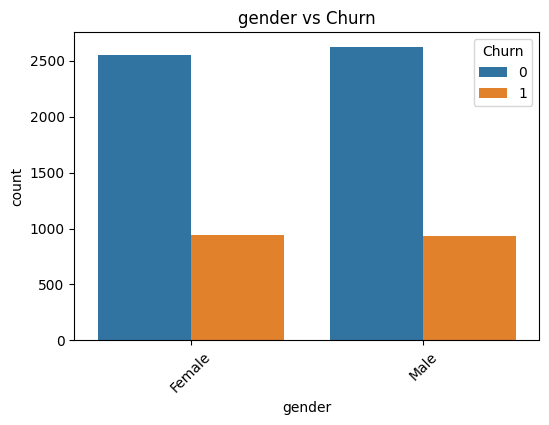

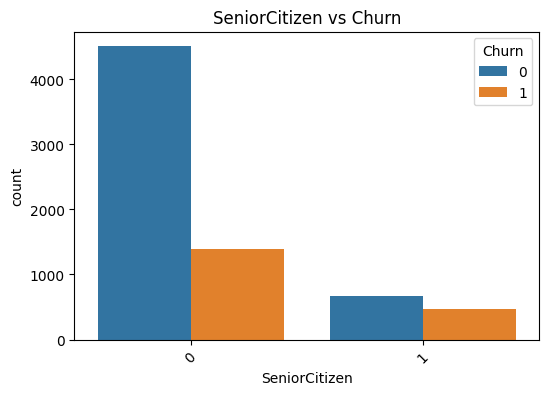

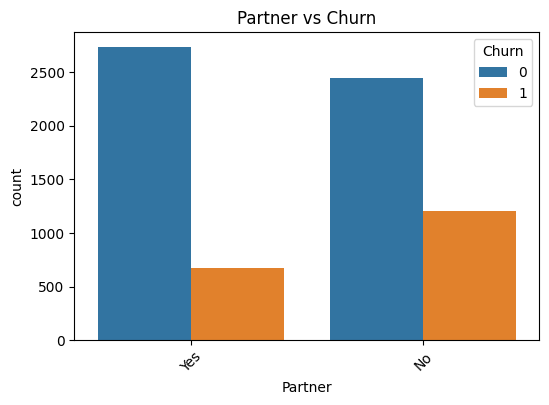

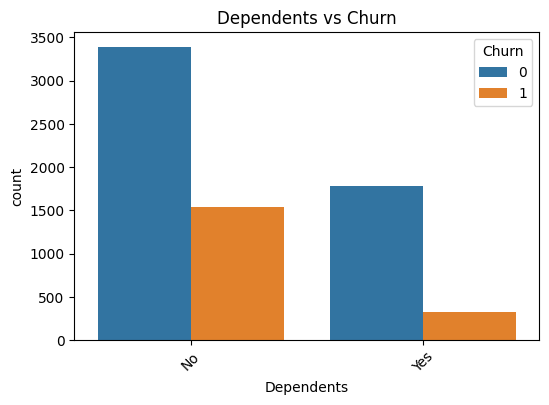

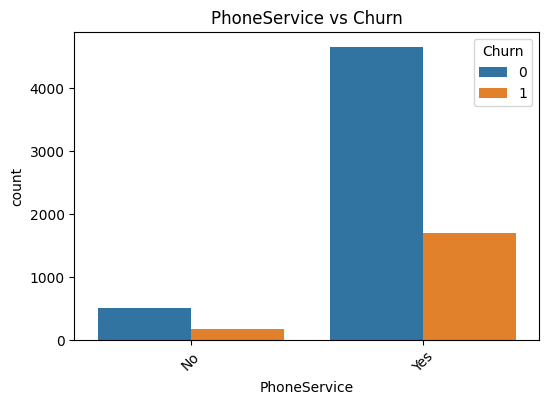

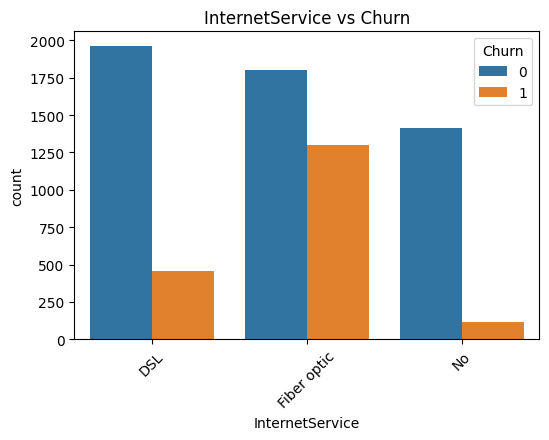

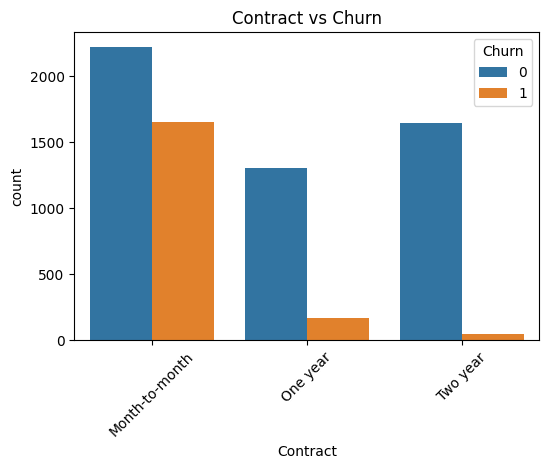

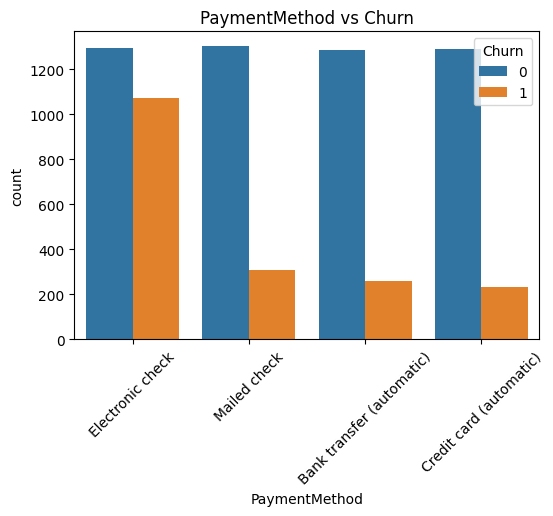

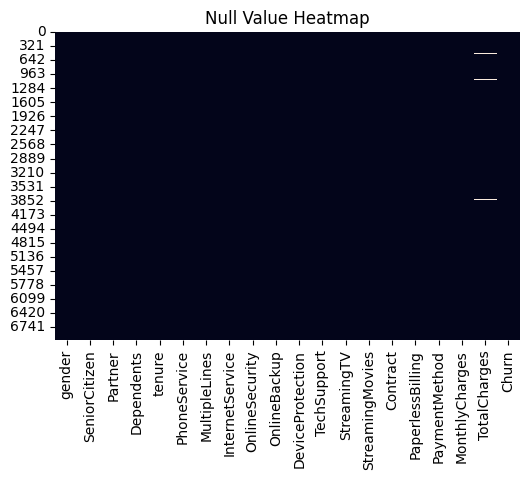

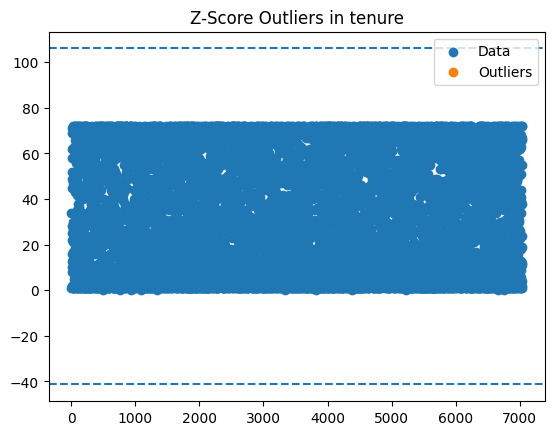

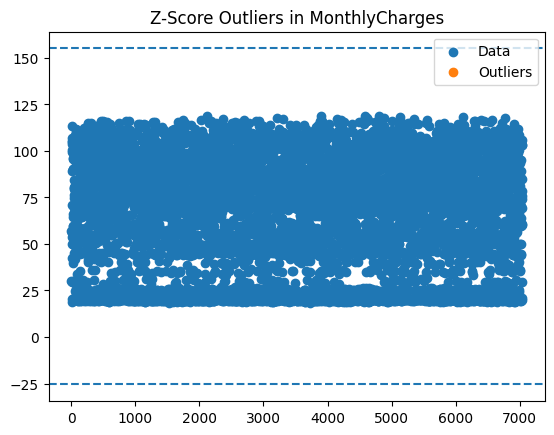

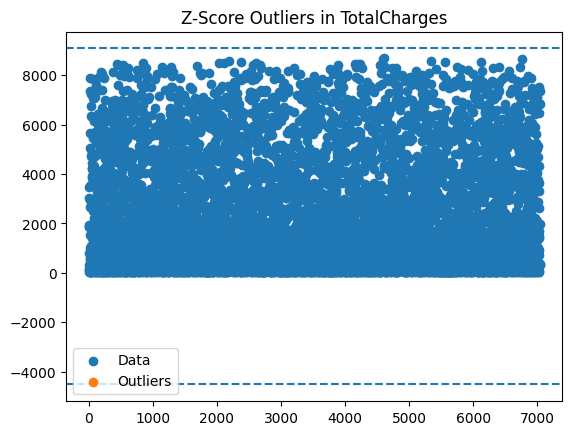

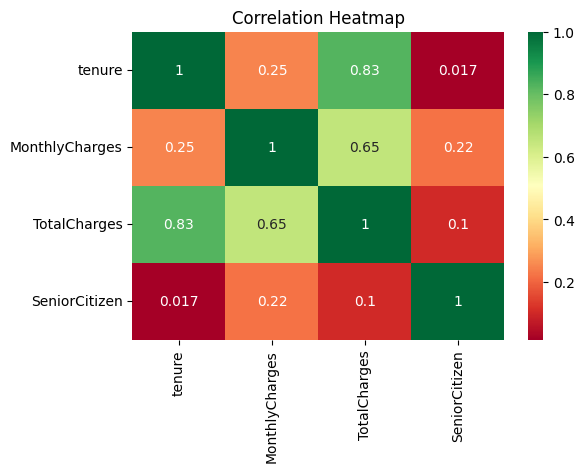

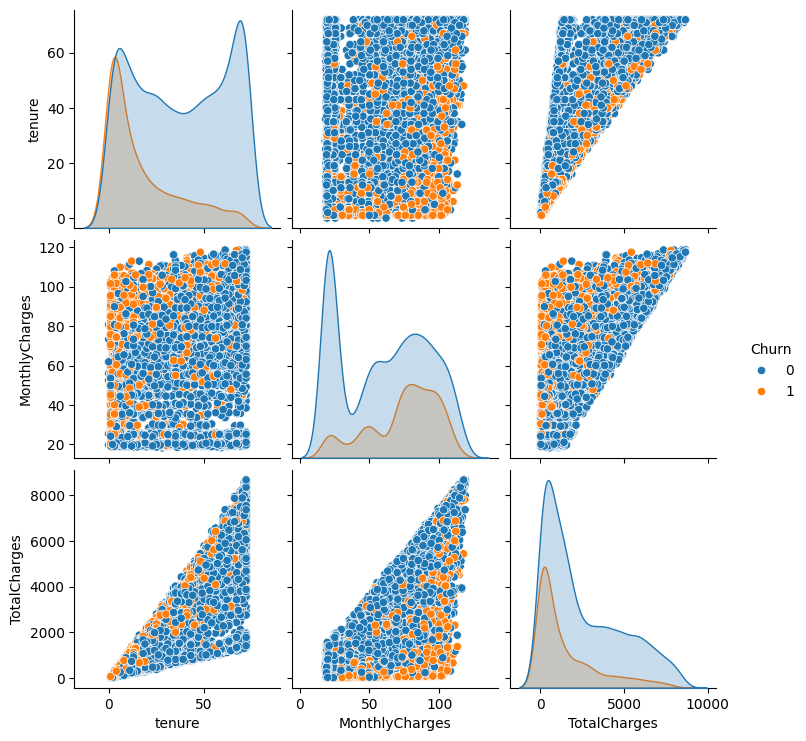

In [6]:
# ================================
# 2. Data Visualization
# ================================

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
            'PhoneService', 'InternetService', 'Contract', 'PaymentMethod']

### Univariate - Distribution of dataset
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

### Multivariate - Feature vs Target
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='Churn', data=df)
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Churn')
    plt.show()

### Missing Value Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Null Value Heatmap")
plt.show()

### Outlier Detection
for col in num_cols:
    mean = df[col].mean()
    std = df[col].std()
    upper = mean + 3 * std
    lower = mean - 3 * std
    outliers = df[(df[col] > upper) | (df[col] < lower)]
    
    plt.figure()
    plt.scatter(range(len(df)), df[col], label="Data")
    plt.scatter(outliers.index, outliers[col], label="Outliers")
    plt.axhline(upper, linestyle="--")
    plt.axhline(lower, linestyle="--")
    plt.title(f"Z-Score Outliers in {col}")
    plt.legend()
    plt.show()

### Feature Relationship: Correlation Matrix
plt.figure(figsize=(6,4))
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']].corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn')
plt.title('Correlation Heatmap')
plt.show()

sns.pairplot(df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']], hue='Churn')
plt.show()

In [7]:
# ================================
# 3. Data Cleaning and Preprocessing 
# ================================

df = df.drop_duplicates()

In [8]:
# ================================
# 4. Feature Engineering 
# ================================

def feature_engineering(X):
    X = X.copy()
    X['AvgCharges'] = X['TotalCharges'] / (X['tenure'] + 1)
    X['AvgCharges'] = X['AvgCharges'].replace([np.inf, -np.inf], 0)
    X['AvgCharges'] = X['AvgCharges'].fillna(0)
    X['TotalCharges_log'] = np.log1p(X['TotalCharges'].fillna(0))
    return X
    
feature_transformer = FunctionTransformer(feature_engineering)

In [9]:
# ================================
# 5. Train Test Split 
# ================================

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
# ================================
# 6. Preprocessing Pipelines
# ================================

# Numerical Pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical Pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# Dynamic Column Selection
preprocessor = ColumnTransformer([
    ("num", num_pipeline, make_column_selector(dtype_include=np.number)),
    ("cat", cat_pipeline, make_column_selector(dtype_exclude=np.number))
])

In [11]:
# ================================
# 7. Full Pipeline 
# ================================

log_pipeline = Pipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight='balanced'))
])

rf_pipeline = Pipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

In [12]:
# ================================
# 8. Model Selection and Training
# ================================

log_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function fea...001C0B22C31A0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keywor

In [13]:
# ================================
# 9. Model Evaluation 
# ================================

def evaluate(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    print(f"\n===== {name} =====")
    print("Accuracy:", acc)
    print("ROC-AUC:", roc)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    
    return roc

roc_log = evaluate(log_pipeline, X_test, y_test, "Logistic Regression")
roc_rf = evaluate(rf_pipeline, X_test, y_test, "Random Forest")


===== Logistic Regression =====
Accuracy: 0.7366548042704626
ROC-AUC: 0.8415917205341994

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.73      0.80      1033
           1       0.50      0.76      0.61       372

    accuracy                           0.74      1405
   macro avg       0.70      0.75      0.70      1405
weighted avg       0.79      0.74      0.75      1405


Confusion Matrix:
 [[751 282]
 [ 88 284]]

===== Random Forest =====
Accuracy: 0.7935943060498221
ROC-AUC: 0.8225090820139691

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.91      0.87      1033
           1       0.66      0.46      0.54       372

    accuracy                           0.79      1405
   macro avg       0.74      0.69      0.70      1405
weighted avg       0.78      0.79      0.78      1405


Confusion Matrix:
 [[944  89]
 [201 171]]


In [14]:
# ================================
# 10. Final Model Selection
# ================================

final_model = rf_pipeline if roc_rf > roc_log else log_pipeline
print("\nSelected Model:", "Random Forest" if final_model == rf_pipeline else "Logistic Regression")


Selected Model: Logistic Regression


In [15]:
# ================================
# 11. Model Serialization
# ================================

joblib.dump(final_model, "Customer_Churn_Prevention.pkl")
print("\nModel saved successfully.")


Model saved successfully.
